## _Track Building after Edge Classification_


- Wrangler Algorithm
- Connected Components (see `trkx_from_gnn.py`)

In [1]:
import sys, os, glob, yaml

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

In [3]:
import pprint
from tqdm import tqdm
import trackml.dataset

In [4]:
import torch
import pytorch_lightning as pl
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
import itertools

In [5]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [6]:
os.environ['EXATRKX_DATA'] = os.path.abspath(os.curdir)

## _PyG Data from GNN Stage_

In [7]:
# Read Event from the Testset
inputdir="run/gnn_evaluation/test"
outputdir="run/stt2_trkx/trkx_from_cc"
os.makedirs(outputdir, exist_ok=True)

In [8]:
all_files = glob.glob(os.path.join(inputdir, "*"))
all_files = sorted(all_files)
print("Total Test Events: ", len(all_files))

Total Test Events:  5000


In [9]:
all_files[:10]

['run/gnn_evaluation/test/5000',
 'run/gnn_evaluation/test/5001',
 'run/gnn_evaluation/test/5002',
 'run/gnn_evaluation/test/5003',
 'run/gnn_evaluation/test/5004',
 'run/gnn_evaluation/test/5005',
 'run/gnn_evaluation/test/5006',
 'run/gnn_evaluation/test/5007',
 'run/gnn_evaluation/test/5008',
 'run/gnn_evaluation/test/5009']

In [10]:
# Use One Event
filename = all_files[1]
evtid = int(os.path.basename(filename))
print("evtid: ", evtid)

evtid:  5001


In [11]:
event = torch.load(filename, map_location=device)
print(event.keys)

['pt', 'pid', 'y_pid', 'modulewise_true_edges', 'x', 'edge_index', 'scores', 'hid', 'event_file', 'layers', 'layerwise_true_edges']


### _(1) - Connected-component Labeling (CCL)_

Connected-component Labeling (CCL) or connected-component analysis (CCA) is an algorithmic application of graph theory, where subsets of connected components are uniquely labeled based on a given **heuristic** (DBSCAN ???). Connected-component labeling is not to be confused with segmentation.

- access `src/cc`

In [12]:
from src import tracks_from_cc

In [13]:
# Input to CCL
hit_id = event.hid
senders = event.edge_index[0]
receivers = event.edge_index[1]
score = event.scores[:event.edge_index.shape[1]]  # score has twice the size of edge_index (flip(0) was used)

In [14]:
# Run CCL method
reco_track = tracks_from_cc (hit_id, score, senders, receivers)
torch.save(reco_track, os.path.join(outputdir, "{}".format(evtid)))

/shared/adeel/anaconda3/envs/exatrkx-cpu/lib/python3.8/site-packages/sklearn/neighbors/_base.py:206: EfficiencyWarning: Precomputed sparse input was not sorted by data.
  warnings.warn(


In [15]:
# See Track Candidates
reco_track.head()

,hit_id,track_id
0,222,0
1,171,1
2,16,2
3,42,3
4,67,-1


In [16]:
# True Edges
true_edges = event.edge_index[:,event.y_pid]
true_edges.shape

torch.Size([2, 172])

In [17]:
# True Edges
false_edges = event.edge_index[:,~event.y_pid]
false_edges.shape

torch.Size([2, 636])

### _Plot True and Reco Events_

In [18]:
from src.drawing import detector_layout
from src.utils_math import polar_to_cartesian

In [19]:
true_track = event

In [20]:
r, phi, ir = true_track.x.T
ir = ir.detach().numpy()*100
x, y = polar_to_cartesian(r.detach().numpy(), phi.detach().numpy())

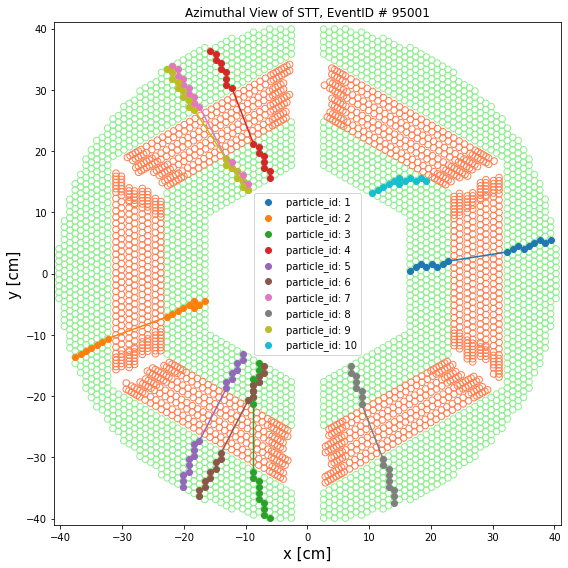

In [21]:
# plot true event
fig, ax = detector_layout(figsize=(8,8))
e_id = int(true_track.event_file[-10:])
p_ids = np.unique(true_track.pid)

for pid in p_ids:
    idx = true_track.pid == pid
    ax.plot(x[idx], y[idx], '-', linewidth=1.5)
    ax.scatter(x[idx], y[idx], label='particle_id: {}'.format(int(pid)))

ax.set_title('Azimuthal View of STT, EventID # {}'.format(e_id))
ax.legend(fontsize=10, loc='best')
fig.tight_layout()
# fig.savefig("true_track.png")

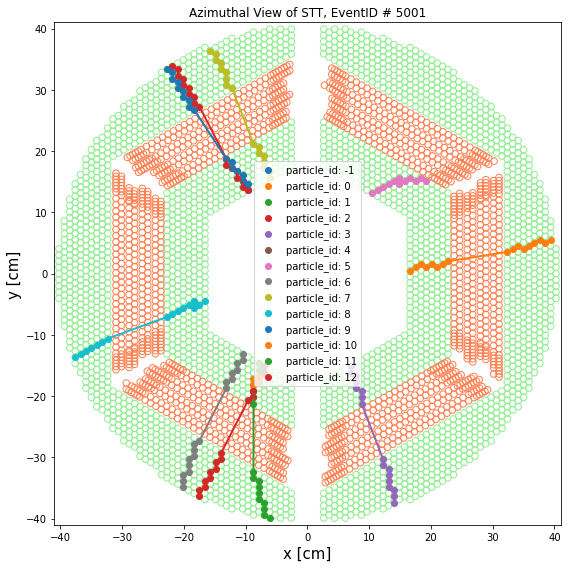

In [22]:
# plot reco event from CCL
fig, ax = detector_layout(figsize=(8,8))
t_ids = np.unique(reco_track.track_id)

# here, (x,y,ir) comes from the true event,
# but idx comes from reco event from CCL

for tid in t_ids:
    idx = reco_track.track_id == tid
    ax.plot(x[idx], y[idx], '-', linewidth=2)
    ax.scatter(x[idx], y[idx], label='particle_id: {}'.format(tid))
    
ax.set_title('Azimuthal View of STT, EventID # {}'.format(evtid))
ax.legend(fontsize=10, loc='best')
fig.tight_layout()
# fig.savefig("reco_track.png")

### _(2) - Wrangler Algorithm_

- Wrangle is in NetworkX

Convert _`PyG::Data`_ to _`NetworkX::DiGraph()`_. In PyG, the [TORCH_GEOMETRIC.UTILS](https://pytorch-geometric.readthedocs.io/en/latest/modules/utils.html) provides _`to_networkx()`_ to convert PyG to NetworkX format. The proceduer to use _Wrangler_ is as follows:

- read testset (`hid, score`)
- convert it to NetworkX structure
- call Wrangler from `src/wrangler`

Let's try it for one event.

In [23]:
import networkx as nx
from torch_geometric.utils import to_networkx
from src import get_tracks

In [41]:
# from https://github.com/exatrkx/exatrkx-neurips19/blob/master/gnn-tracking/heptrkx/nx_graph/utils_plot.py
def get_pos(Gp):
    pos = {}
    for node in Gp.nodes():
        # r, phi, z = Gp.node[node]['pos'][:3]
        r,phi = G.nodes[node]['x'][:2]
        x = r * np.cos(phi)
        y = r * np.sin(phi)
        pos[node] = np.array([x, y])
    return pos

def plot_networkx(G, ax=None, only_true=False):
    """G is networkx graph,
    node feature: {'pos': [r, phi, z]}
    edge feature: {"solution": []}
    """
    if ax is None:
        fig, ax = plt.subplots()

    n_edges = len(G.edges())
    edge_colors = [0.]*n_edges
    true_edges = []
    for iedge,edge in enumerate(G.edges(data=True)):
        if int(edge[2]['y_pid']) == 1:
            edge_colors[iedge] = 'r'
            true_edges.append((edge[0], edge[1]))
        else:
            edge_colors[iedge] = 'grey'

    Gp = nx.edge_subgraph(G, true_edges) if only_true else G
    edge_colors = ['k']*len(true_edges) if only_true else edge_colors 

    pos = get_pos(Gp)

    nx.draw(Gp, pos, node_color='#A0CBE2', edge_color=edge_colors,
       width=0.5, with_labels=False, node_size=1, ax=ax, arrows=False)
    
    plt.savefig("Graph.png", format="PNG")

In [42]:
data = torch.load(filename, map_location=device)
print(data.keys)

['pt', 'pid', 'y_pid', 'modulewise_true_edges', 'x', 'edge_index', 'scores', 'hid', 'event_file', 'layers', 'layerwise_true_edges']


In [43]:
data.num_nodes, data.num_edges, data.num_features

(171, 2, 3)

In [44]:
data.is_directed()

True

In [45]:
G = to_networkx(data, node_attrs=['x'], edge_attrs=['scores', 'y_pid'])

In [46]:
track_cand = get_tracks(G, th=0.1, th_re=0.8, feature_name='scores', with_fit=False)

In [51]:
track_cand

In [47]:
print(track_cand[0])

DiGraph with 17 nodes and 16 edges


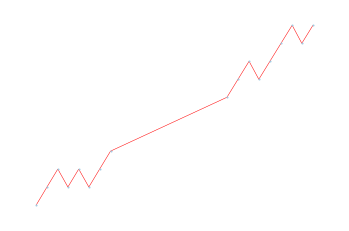

In [48]:
plot_networkx(track_cand[0])

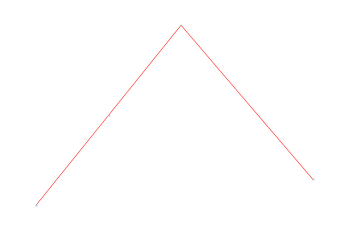

In [57]:
plot_networkx(track_cand[12])

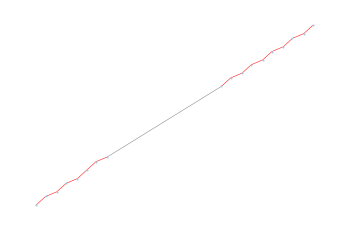

In [50]:
plot_networkx(track_cand[2])